100%|██████████| 501/501 [00:01<00:00, 260.45it/s]


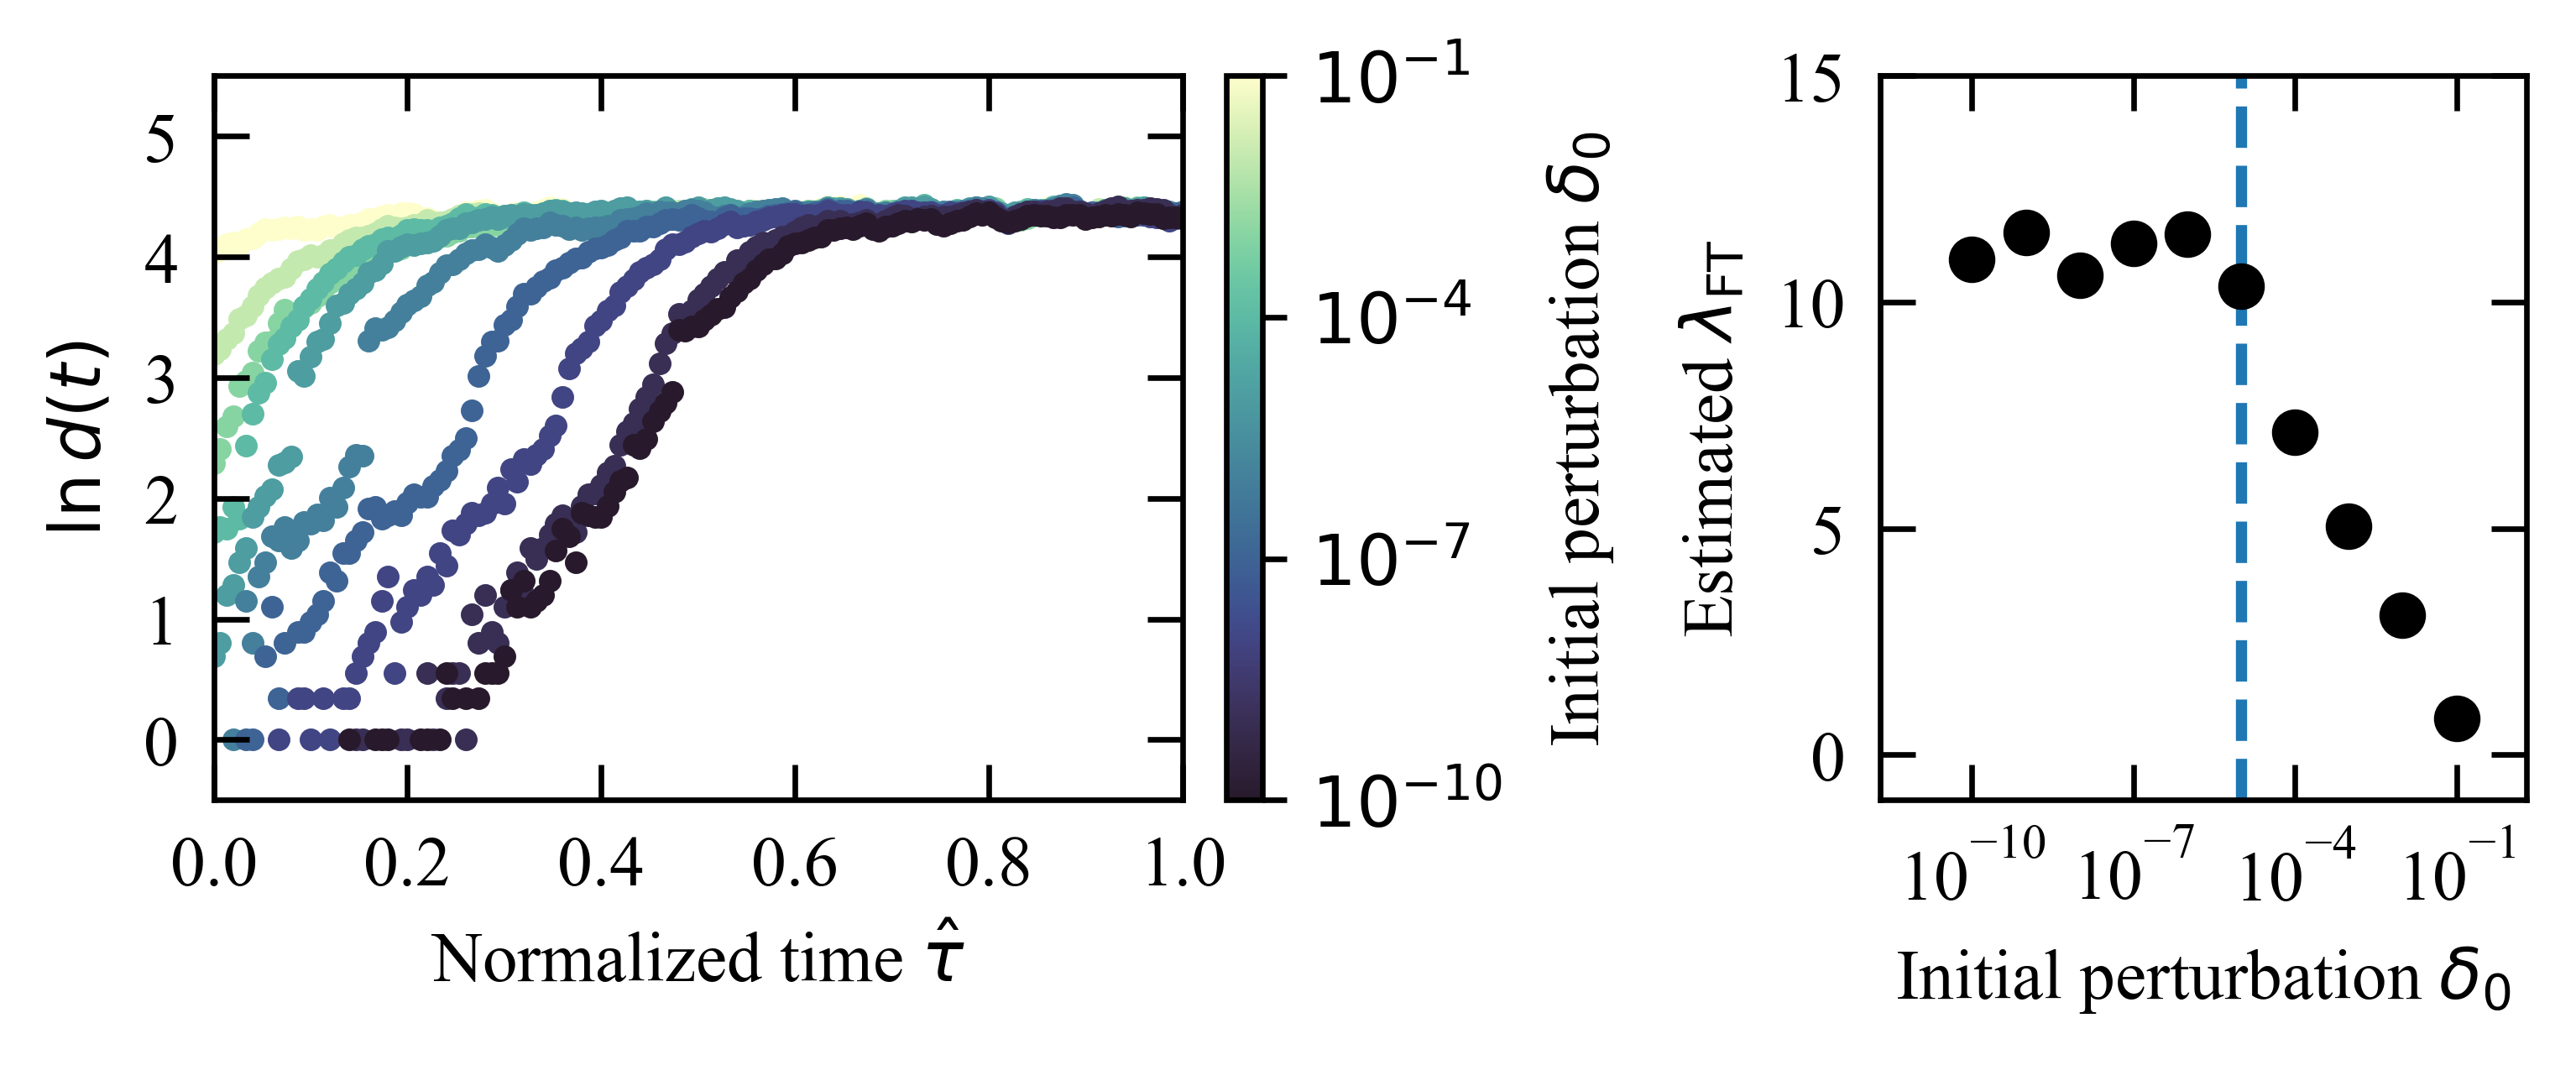

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean
import meanderpy as mp
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext, FixedLocator
from matplotlib.cm import ScalarMappable

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.dpi"] = 600

def run_meander_simulation(freq_multiplier: float,
                           amplitude: float,
                           *,
                           n_perturb: int = 0,
                           perturb_magnitude: float = 0.0,
                           nit: int = 501,
                           saved_ts: int = 1):
    W, D = 50.0, 1.0
    depths  = D * np.ones(nit)
    pad, deltas = 0, 50.0
    Cfs     = 0.0065 * np.ones(nit)
    crdist  = 5 * W
    kl      = 500.0 / (365*24*60*60.0)
    kv      = 1.0e-12
    dt      = 0.2 * 0.5 * 365*24*60*60.0
    dens    = 1000
    t1 = t2 = t3 = 0
    aggr_factor = 0

    x_initial = np.linspace(0.1, 10_000, 1500)
    y_initial = (amplitude * 100.0) * np.sin(freq_multiplier * np.pi * x_initial / 10_000.0)
    if n_perturb and perturb_magnitude:
        y_initial[len(x_initial)//2] += perturb_magnitude
    z_initial = np.zeros_like(x_initial)

    ch  = mp.Channel(x_initial, y_initial, z_initial, W, depths[0])
    chb = mp.ChannelBelt([ch], [], [0.0], [])
    chb.migrate(nit, saved_ts, deltas, pad, crdist,
                depths, Cfs, kl, kv, dt, dens,
                t1, t2, t3, aggr_factor)
    return chb

def rasterize_channel(x, y, rows, cols, extent, n_seg=1000):
    x_min, x_max, y_min, y_max = extent
    dx = (x_max - x_min) / cols
    dy = (y_max - y_min) / rows
    canvas = np.zeros((rows, cols), dtype=np.int8)
    for x0, y0, x1, y1 in zip(x[:-1], y[:-1], x[1:], y[1:]):
        xs = np.linspace(x0, x1, n_seg)
        ys = np.linspace(y0, y1, n_seg)
        c = ((xs - x_min) / dx).astype(int)
        r = ((ys - y_min) / dy).astype(int)
        m = (0 <= c) & (c < cols) & (0 <= r) & (r < rows)
        canvas[r[m], c[m]] = 1
    return canvas

def compute_log_norms_for_perturbations(chb_ref, perturbed_runs, perturbation_magnitudes,
                                        extent, grid_rows=500, grid_cols=1000, n_seg_rasterize=10):
    timesteps = len(chb_ref.channels)
    log_norms = {}
    for i, dY in enumerate(perturbation_magnitudes):
        chb_pert = perturbed_runs[i]
        all_norms = np.full((timesteps,), np.nan)
        for t in range(timesteps):
            ch0 = chb_ref.channels[t]
            ch1 = chb_pert.channels[t]
            if ch0 is None or ch1 is None: 
                continue
            x0, y0 = getattr(ch0, 'x', None), getattr(ch0, 'y', None)
            x1, y1 = getattr(ch1, 'x', None), getattr(ch1, 'y', None)
            if any(v is None for v in (x0, y0, x1, y1)) or len(x0) < 2 or len(x1) < 2:
                continue
            try:
                g0 = rasterize_channel(x0, y0, grid_rows, grid_cols, extent, n_seg_rasterize)
                g1 = rasterize_channel(x1, y1, grid_rows, grid_cols, extent, n_seg_rasterize)
            except Exception:
                continue
            grid_diff = g1 - g0
            norm = np.linalg.norm(grid_diff)
            all_norms[t] = max(norm, 0.0)

        avg_norm = all_norms
        valid = ~np.isnan(avg_norm)
        log_norm = np.full_like(avg_norm, np.nan)
        if np.any(valid):
            v = avg_norm[valid]
            v[v < 1e-15] = 1e-15
            log_norm[valid] = np.log(v)
        log_norms[dY] = log_norm
    return log_norms

freq, A = 30.0, 3.0
extent = (0, 10_000, -2500, 2500)
grid_rows, grid_cols = 500, 1000
perturbation_magnitudes = [10**(-i) for i in range(1, 11)] 
saved_ts = 1

chb_ref = run_meander_simulation(freq, A)
perturbed_runs = [run_meander_simulation(freq, A, n_perturb=1, perturb_magnitude=dY)
                  for dY in perturbation_magnitudes]

log_norms = compute_log_norms_for_perturbations(
    chb_ref=chb_ref,
    perturbed_runs=perturbed_runs,
    perturbation_magnitudes=perturbation_magnitudes,
    extent=extent,
    grid_rows=grid_rows,
    grid_cols=grid_cols,
    n_seg_rasterize=100
)

slopes = []
for dY in perturbation_magnitudes:
    y = np.array(log_norms[dY])
    x = np.arange(len(y)) * saved_ts
    mask = (x >= 50) & (x <= 200) & (y >= 0)
    x_masked, y_masked = x[mask], y[mask]
    if len(x_masked) < 5:
        slopes.append(np.nan)
        continue
    x_norm = (x_masked - 50) / 150
    n_fit = min(50, len(x_norm))
    A = np.vstack([x_norm[:n_fit], np.ones(n_fit)]).T
    m, _ = np.linalg.lstsq(A, y_masked[:n_fit], rcond=None)[0]
    slopes.append(m)
slopes = np.array(slopes)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(5, 2),
    gridspec_kw={'width_ratios': [1.5, 1], 'wspace': 0.05},
    constrained_layout=True
)

cmap = cmocean.cm.deep_r
norm = LogNorm(vmin=min(perturbation_magnitudes), vmax=max(perturbation_magnitudes))
sm = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

for delta0 in perturbation_magnitudes:
    color = cmap(norm(delta0))
    y = np.array(log_norms[delta0])
    x = np.arange(len(y)) * saved_ts
    mask = (x >= 50) & (x <= 200)
    x_norm = (x[mask] - 50) / 150
    ax1.scatter(x_norm, y[mask], color=color, s=5)

ax1.set_xlabel(r'Normalized time $\hat{\tau}$')
ax1.set_ylabel(r'$\ln d(t)$')
ax1.set_xlim(0, 1)
ax1.set_ylim(-0.5, 5.5)
ax1.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.set_yticks([0, 1, 2, 3, 4, 5])
ax1.tick_params(axis='both', direction='in', top=True, right=True, pad=5, length=5)

cb_ticks = [1e-1, 1e-4, 1e-7, 1e-10]
cbar = fig.colorbar(sm, ax=ax1, pad=0.0)
cbar.set_label(r'Initial perturbation $\delta_0$', labelpad=6)
cbar.set_ticks(cb_ticks)
cbar.ax.set_yticklabels([fr"$10^{{{int(np.log10(t))}}}$" for t in cb_ticks])

finite = np.isfinite(slopes)
ax2.scatter(np.array(perturbation_magnitudes)[finite], slopes[finite], color='k', s=32, zorder=2)
ax2.set_xscale('log')
ax2.set_xlim(2e-12, 2e0)
ax2.set_ylim(-1, 15)
ax2.xaxis.set_major_locator(FixedLocator(cb_ticks))
ax2.xaxis.set_major_formatter(LogFormatterMathtext())
ax2.set_xlabel(r'Initial perturbation $\delta_0$')
ax2.set_ylabel(r'Estimated $\lambda_{\mathrm{FT}}$')
ax2.tick_params(axis='both', direction='in', top=True, right=True, pad=5, length=5)
ax2.axvline(1e-5, color='tab:blue', linestyle='--', linewidth=1.6, zorder=1)
plt.show()